In [1]:

import os
print(os.getcwd())
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from Backtest import Backtest
from enum import Enum

c:\ML_Projects\ML_Projects\AlgoTrading


# Build SMA Cross over strategy
<br>
We will build a Simpel Moving Average CrossOver strategy based on the 5 minutes timeframe. <br>

## Loade data

In [2]:
df_GOLD_Raw = pd.read_parquet(f"../Data/GOLD_1M.parquet")
df_baseline = pd.read_parquet(f"../Data/EURUSD_M1.parquet")
df_GOLD_Raw.head()

,open,high,low,close,volume
time,,,,,
2019-10-15 12:13:00,1492.87,1493.36,1492.77,1493.33,62
2019-10-15 12:14:00,1493.36,1493.47,1493.06,1493.07,47
2019-10-15 12:15:00,1493.09,1493.28,1492.97,1493.07,70
2019-10-15 12:16:00,1493.08,1493.35,1493.07,1493.35,28
2019-10-15 12:17:00,1493.30,1493.36,1493.14,1493.28,38


In [3]:
def get_resampled(df, high_freq='4h'):
    volume_col = 'tick_volume' if 'tick_volume' in df.columns else 'volume'

    df_high_sample_rate = df.resample(high_freq).agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        volume=(volume_col, 'sum'),
        High_time=('high', lambda x: x.idxmax() if len(x) > 0 else None),
        Low_time=('low', lambda x: x.idxmin() if len(x) > 0 else None)
    )

    df_high_sample_rate = df_high_sample_rate.dropna()

    return df_high_sample_rate

In [4]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
df_baseline = get_resampled(df_baseline, high_freq="5min")

## Build SMA Crossover
### Version 1

In [5]:
df_GOLD["SMA_fast"] = df_GOLD["close"].rolling(window=30).mean()
df_GOLD["SMA_slow"] = df_GOLD["close"].rolling(window=60).mean()

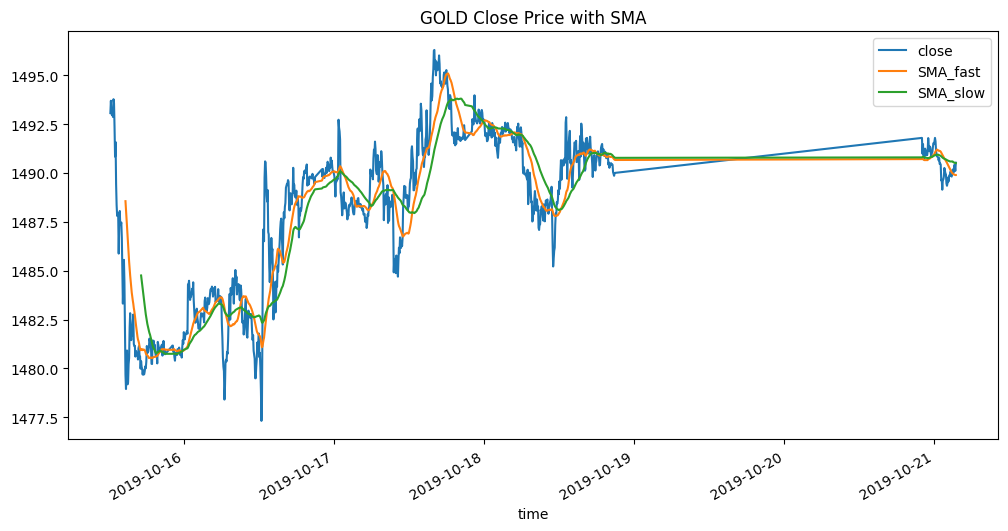

In [6]:
df_GOLD[["close", "SMA_fast", "SMA_slow"]][:1000].plot(figsize=(12, 6))
plt.title("GOLD Close Price with SMA")
plt.show()

In [7]:
df_GOLD['position'] = np.nan
df_GOLD.loc[df_GOLD['SMA_fast'] > df_GOLD['SMA_slow'], 'position'] = 1
df_GOLD.loc[df_GOLD['SMA_fast'] < df_GOLD['SMA_slow'], 'position'] = -1
df_GOLD['position'] = df_GOLD['position'].ffill().fillna(0)


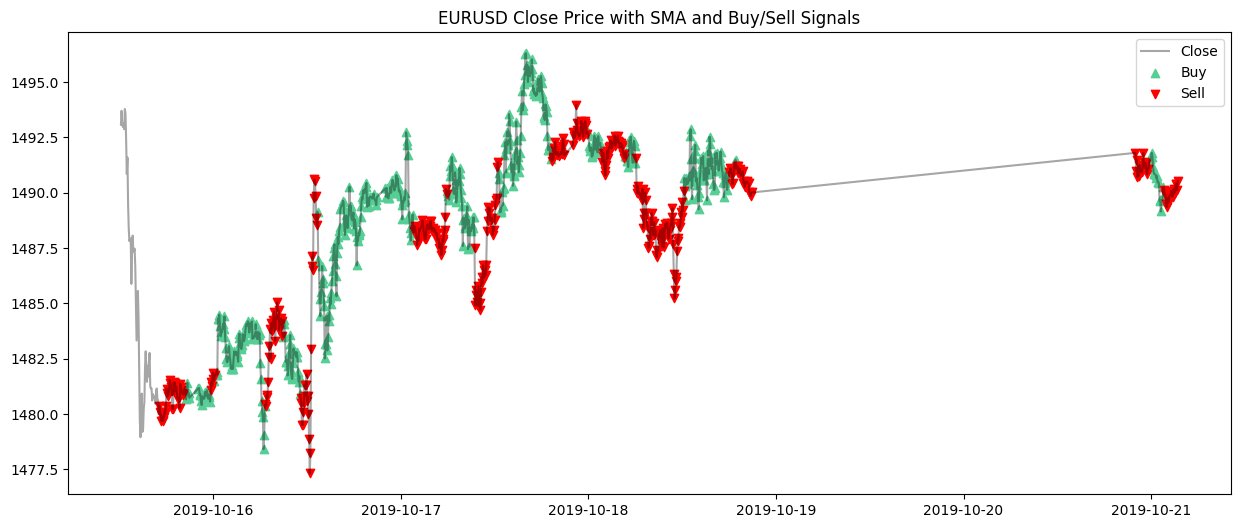

In [8]:
df_GOLD_Snapshot = df_GOLD[:1000]

long_mask = df_GOLD_Snapshot["position"] == 1
short_mask = df_GOLD_Snapshot["position"] == -1

# Adapt the size of the graph
plt.figure(figsize=(15, 6))

# Plot close price for context
plt.plot(df_GOLD_Snapshot.index, df_GOLD_Snapshot["close"], color="black", alpha=0.35, label="Close")

# Plot buy/sell signals
plt.scatter(df_GOLD_Snapshot.index[long_mask], df_GOLD_Snapshot.loc[long_mask, "close"], color="#57CE95", marker="^", label="Buy")
plt.scatter(df_GOLD_Snapshot.index[short_mask], df_GOLD_Snapshot.loc[short_mask, "close"], color="red", marker="v", label="Sell")

plt.title("EURUSD Close Price with SMA and Buy/Sell Signals")
plt.legend()
plt.show()

Backtest the strategy.

In [9]:
class TimeFrame(Enum):
  DAILY = 252
  MIN_1 = 252 * 24 * 60
  MIN_5 = 252 * 24 * 12
  MIN_10 = 252 * 24 * 6
  HOUR_1 = 252 * 24
  HOUR_6 = 252 * 4

selected_timeframe = TimeFrame.MIN_5

def drawdown_function(returns):

  # Build an equity curve from periodic returns, then compute peak-to-trough drawdown
  equity_curve = (1 + returns.dropna()).cumprod()
  running_max = equity_curve.cummax()
  drawdown = equity_curve / running_max - 1
  return drawdown

def BackTest(strategy_data, baseline_data, annualiazed_scalar=selected_timeframe):

  # Accept either enum or numeric annualization scalar
  annualized_scalar = annualiazed_scalar.value if isinstance(annualiazed_scalar, Enum) else float(annualiazed_scalar)

  # Ensure a clean strategy return series
  serie = strategy_data.copy()
  if isinstance(serie, pd.DataFrame):
    if "return" in serie.columns:
      serie = serie["return"]
    else:
      serie = serie.iloc[:, 0]
  serie = serie.rename("return").dropna()
  if not serie.index.is_unique:
    serie = serie[~serie.index.duplicated(keep="first")]

  # Build benchmark return series from close prices
  if isinstance(baseline_data, pd.DataFrame):
    if "close" in baseline_data.columns:
      baseline_price = baseline_data["close"]
    else:
      baseline_price = baseline_data.iloc[:, 0]
  else:
    baseline_price = baseline_data

  baseline = baseline_price.pct_change(1).rename("EURUSD").dropna()
  if not baseline.index.is_unique:
    baseline = baseline[~baseline.index.duplicated(keep="first")]

  # Align by timestamps to avoid mixing unrelated bars
  val = pd.concat((serie, baseline), axis=1, join="inner").dropna()
  if val.empty:
    raise ValueError("No overlapping timestamps between strategy and benchmark after alignment.")

  # Final compounded returns
  final_return_portfolio = (1 + val["return"]).prod() - 1
  final_return_benchmark = (1 + val["EURUSD"]).prod() - 1

  # Compute drawdown on aligned strategy returns
  drawdown = drawdown_function(val["return"]) * 100

  # Compute max drawdown
  max_drawdown = -np.min(drawdown)

  # Put a subplots
  fig, (cum, dra) = plt.subplots(1, 2, figsize=(20, 6))

  # Put a Suptitle
  fig.suptitle("Backtesting", size=20)

  # Returns equity curves
  cum.plot(((1 + val["return"]).cumprod() - 1) * 100, color="#39B3C7")

  # EURUSD equity curve
  cum.plot(((1 + val["EURUSD"]).cumprod() - 1) * 100, color="#B85A0F")

  # Put a legend
  cum.legend(["Portfolio", "EURUSD"])

  # Set individual title
  cum.set_title("Cumulative Return", size=13)

  cum.set_ylabel("Cumulative Return %", size=11)

  # Put the drawdown
  dra.fill_between(drawdown.index, 0, drawdown, color="#C73954", alpha=0.65)

  # Set individual title
  dra.set_title("Drawdown", size=13)

  dra.set_ylabel("drawdown in %", size=11)

  # Plot the graph
  plt.show()

  # Compute the sortino
  downside_std = val.loc[val["return"] < 0, "return"].std()
  sortino = np.nan if (pd.isna(downside_std) or downside_std == 0) else np.sqrt(annualized_scalar) * val["return"].mean() / downside_std

  # Compute the beta
  benchmark_var = np.var(val["EURUSD"].values)
  beta = np.nan if benchmark_var == 0 else np.cov(val[["return", "EURUSD"]].values, rowvar=False)[0][1] / benchmark_var

  # Compute the alpha
  alpha = np.nan if pd.isna(beta) else annualized_scalar * (val["return"].mean() - beta * val["EURUSD"].mean())

  # Print the statistics
  print(f"Final Return Portfolio: {final_return_portfolio:.2%}")
  print(f"Final Return EURUSD: {final_return_benchmark:.2%}")
  print(f"Sortino: {np.round(sortino,3)}")
  print(f"Beta: {np.round(beta,3)}")
  print(f"Alpha: {np.round(alpha*100,3)} %")
  print(f"MaxDrawdown: {np.round(max_drawdown,3)} %")

  return {
    "final_return_portfolio": final_return_portfolio,
    "final_return_benchmark": final_return_benchmark,
    "sortino": sortino,
    "beta": beta,
    "alpha": alpha,
    "max_drawdown": max_drawdown,
  }

def SMA_strategy(df=df_GOLD_Raw, SMA_Fast = 30, SMA_Slow = 60, transaction_cost=0.0):
  
  df = df.copy()

  # Create fast and slow SMAs
  df["SMA fast"] = df["close"].rolling(SMA_Fast).mean()
  df["SMA slow"] = df["close"].rolling(SMA_Slow).mean()

  df["position"] = np.nan

  # Create the condition
  df.loc[(df["SMA fast"] > df["SMA slow"]), "position"] = 1
  df.loc[(df["SMA fast"] < df["SMA slow"]), "position"] = -1

  # Keep previous position between signals, then flat before first signal
  df["position"] = df["position"].ffill().fillna(0)

  df["pct"] = df["close"].pct_change(1)

  # Apply transaction cost only when a position change occurs
  turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
  df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

  # Keep only valid strategy returns; avoids plotting an all-NaN series
  ret = df["return"].dropna()
  if ret.empty:
    raise ValueError("No valid returns. Download more history or reduce SMA windows.")

  return ret

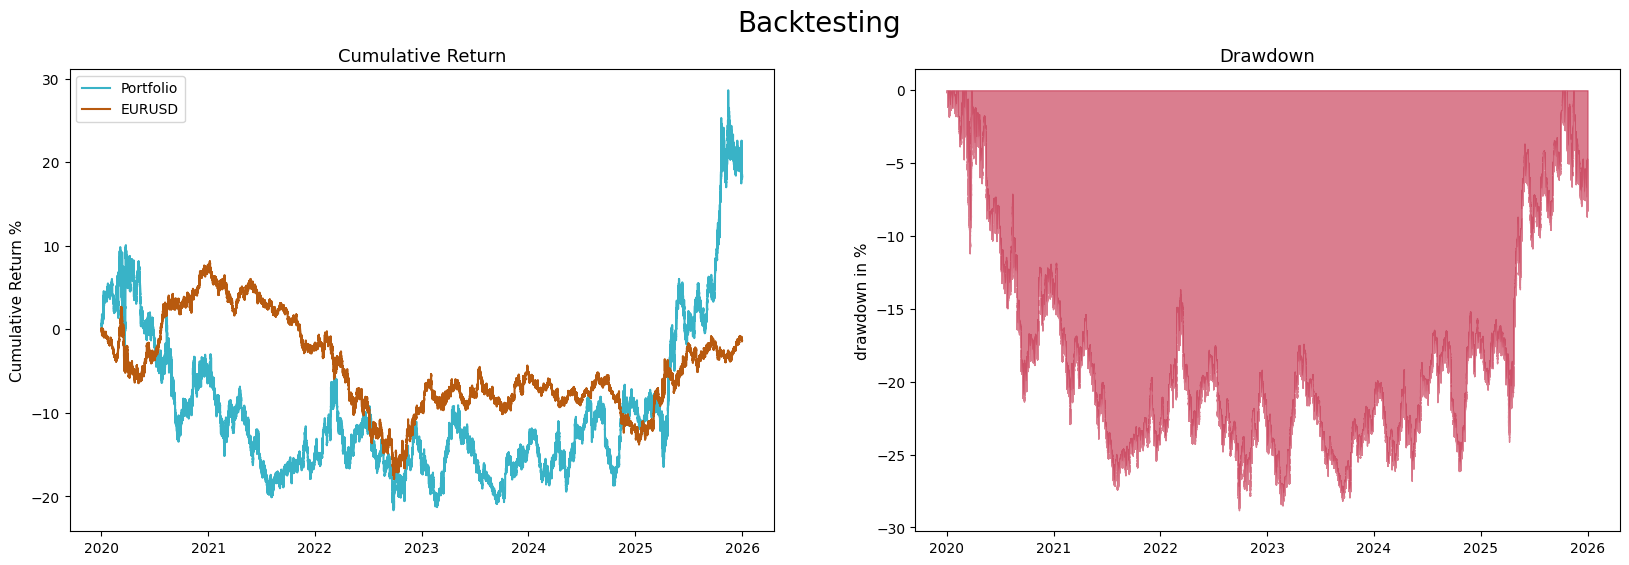

Final Return Portfolio: 18.24%
Final Return EURUSD: -1.29%
Sortino: 0.343
Beta: -0.001
Alpha: 4.225 %
MaxDrawdown: 28.826 %


In [10]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
dfc = SMA_strategy(df_GOLD, SMA_Fast = 30, SMA_Slow = 60, transaction_cost=0.00001)
metrics = BackTest(dfc, df_baseline, selected_timeframe)

### Version 1.1
Try to find the best setting, for the fast and slow SMA

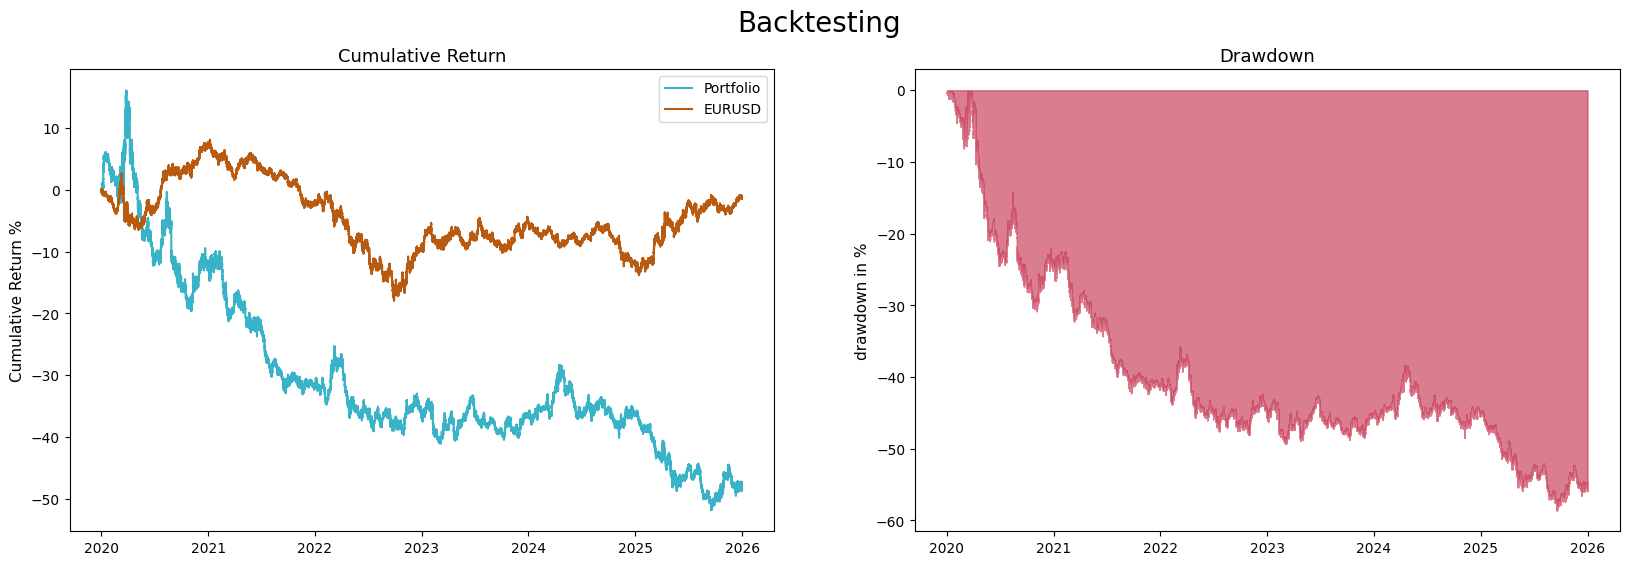

Final Return Portfolio: -48.49%
Final Return EURUSD: -1.29%
Sortino: -0.85
Beta: -0.001
Alpha: -10.242 %
MaxDrawdown: 58.58 %


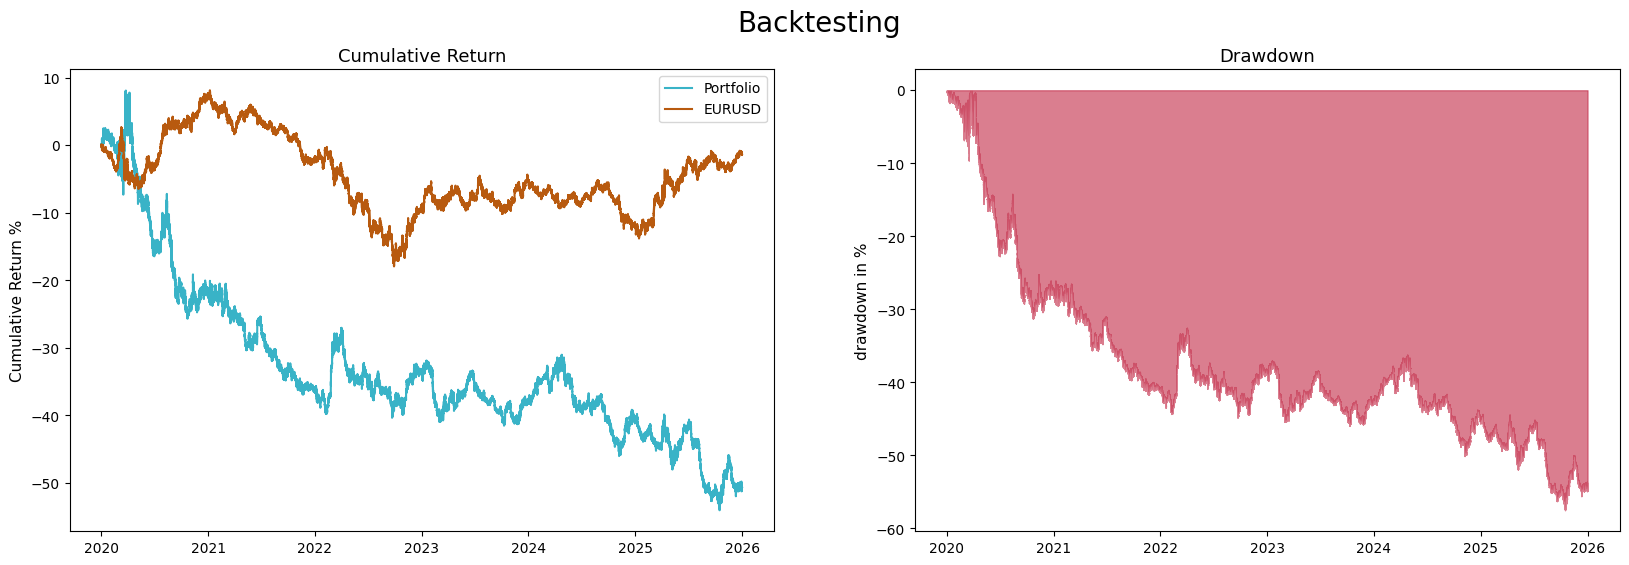

Final Return Portfolio: -50.74%
Final Return EURUSD: -1.29%
Sortino: -0.91
Beta: -0.004
Alpha: -11.018 %
MaxDrawdown: 57.514 %


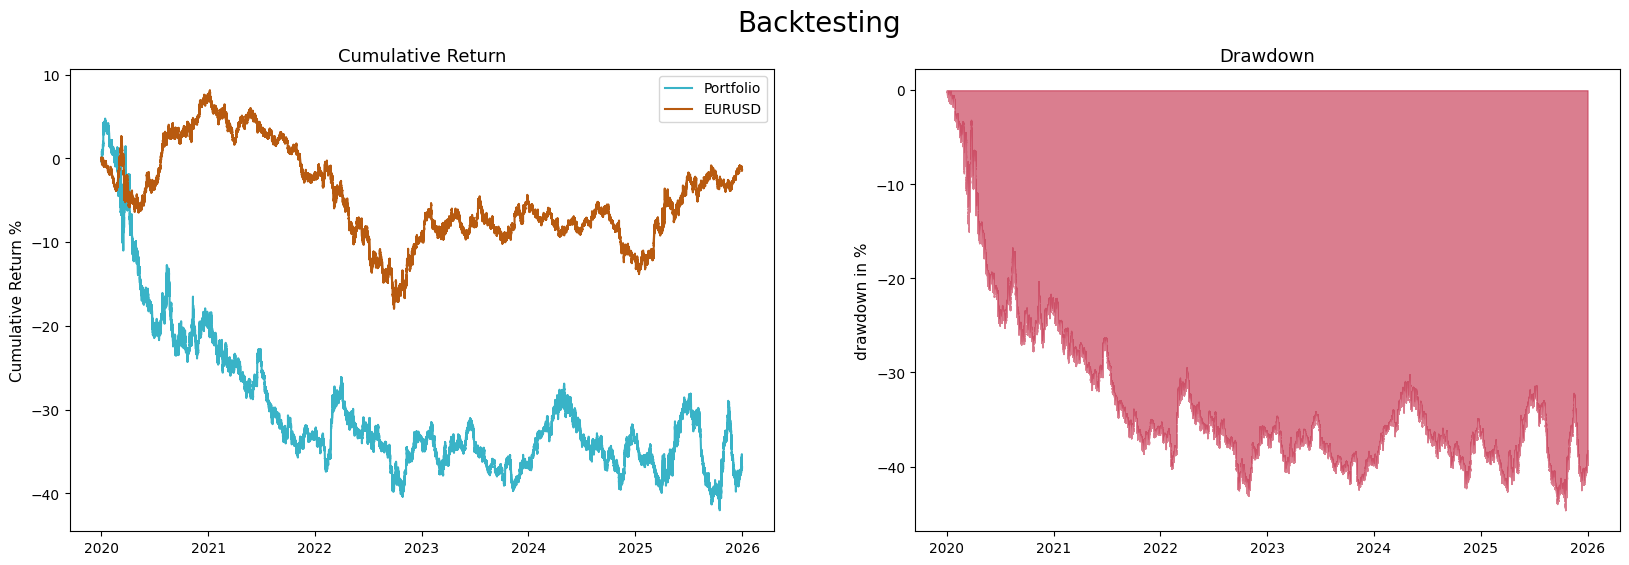

Final Return Portfolio: -36.93%
Final Return EURUSD: -1.29%
Sortino: -0.554
Beta: -0.002
Alpha: -6.716 %
MaxDrawdown: 44.652 %


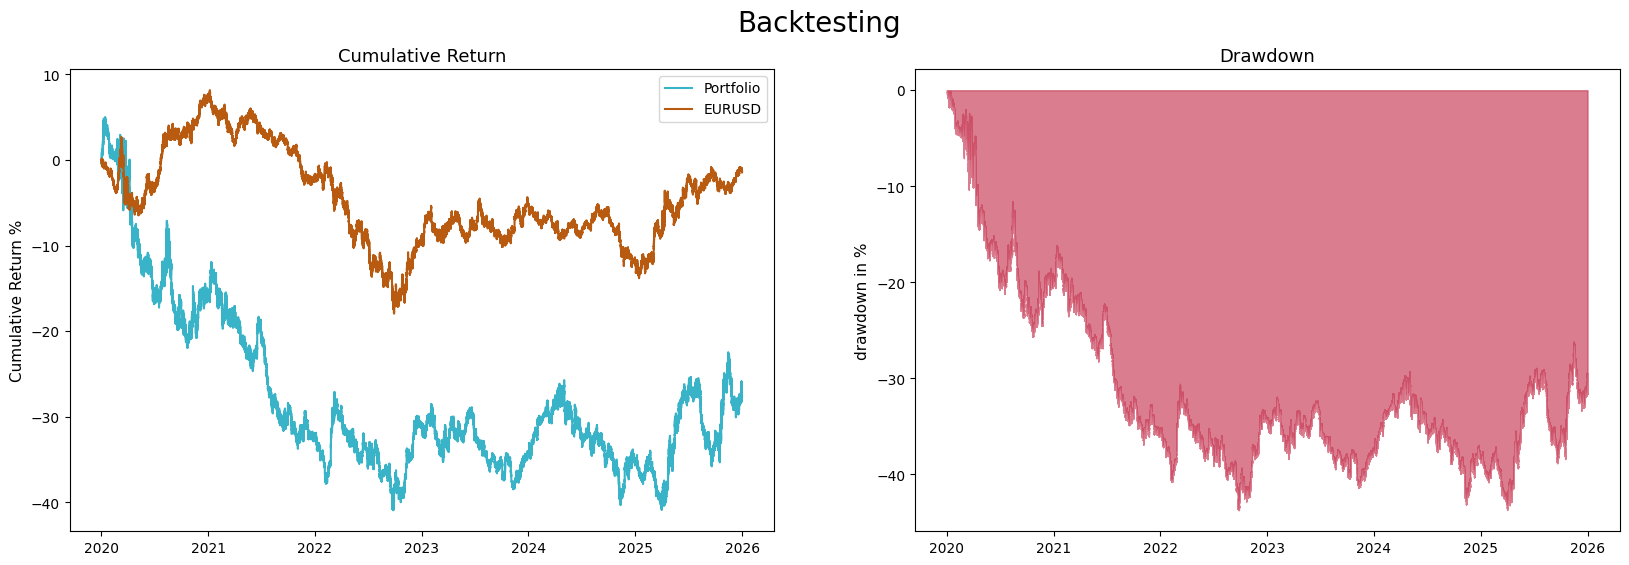

Final Return Portfolio: -27.62%
Final Return EURUSD: -1.29%
Sortino: -0.357
Beta: -0.002
Alpha: -4.319 %
MaxDrawdown: 43.743 %


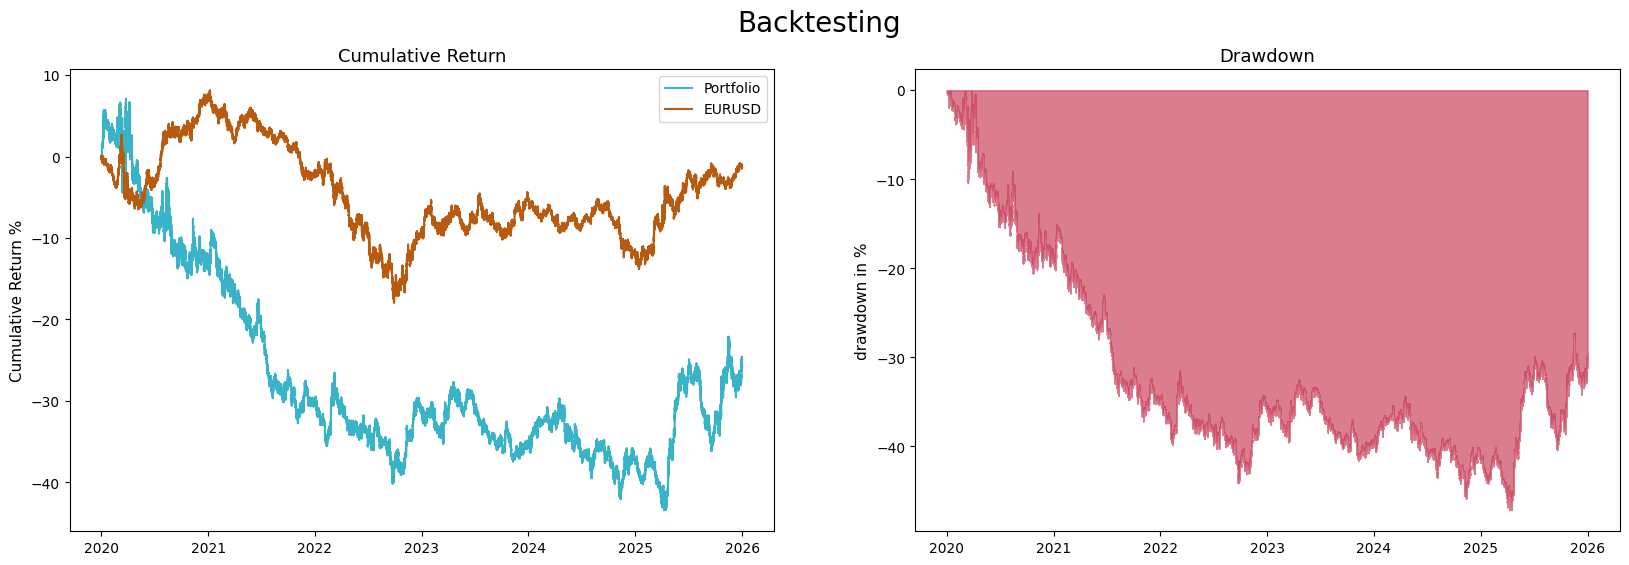

Final Return Portfolio: -25.76%
Final Return EURUSD: -1.29%
Sortino: -0.321
Beta: -0.0
Alpha: -3.877 %
MaxDrawdown: 47.185 %


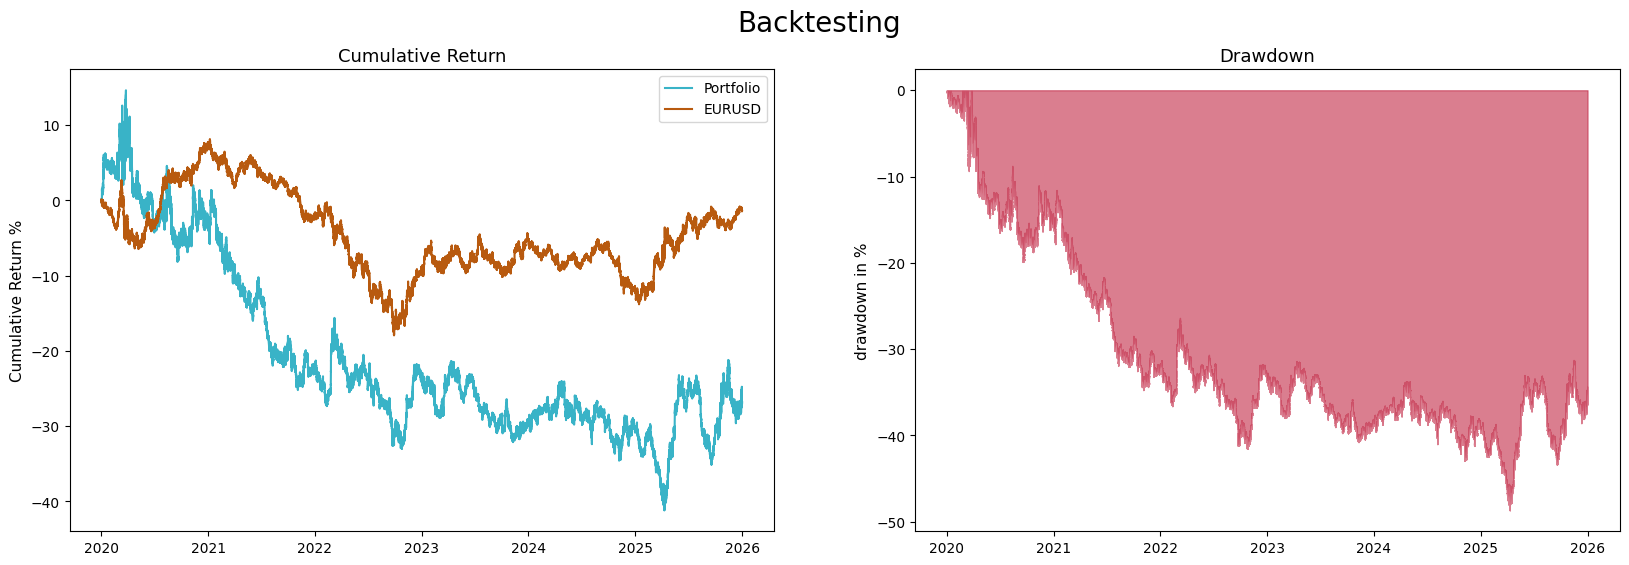

Final Return Portfolio: -26.88%
Final Return EURUSD: -1.29%
Sortino: -0.343
Beta: 0.001
Alpha: -4.141 %
MaxDrawdown: 48.691 %


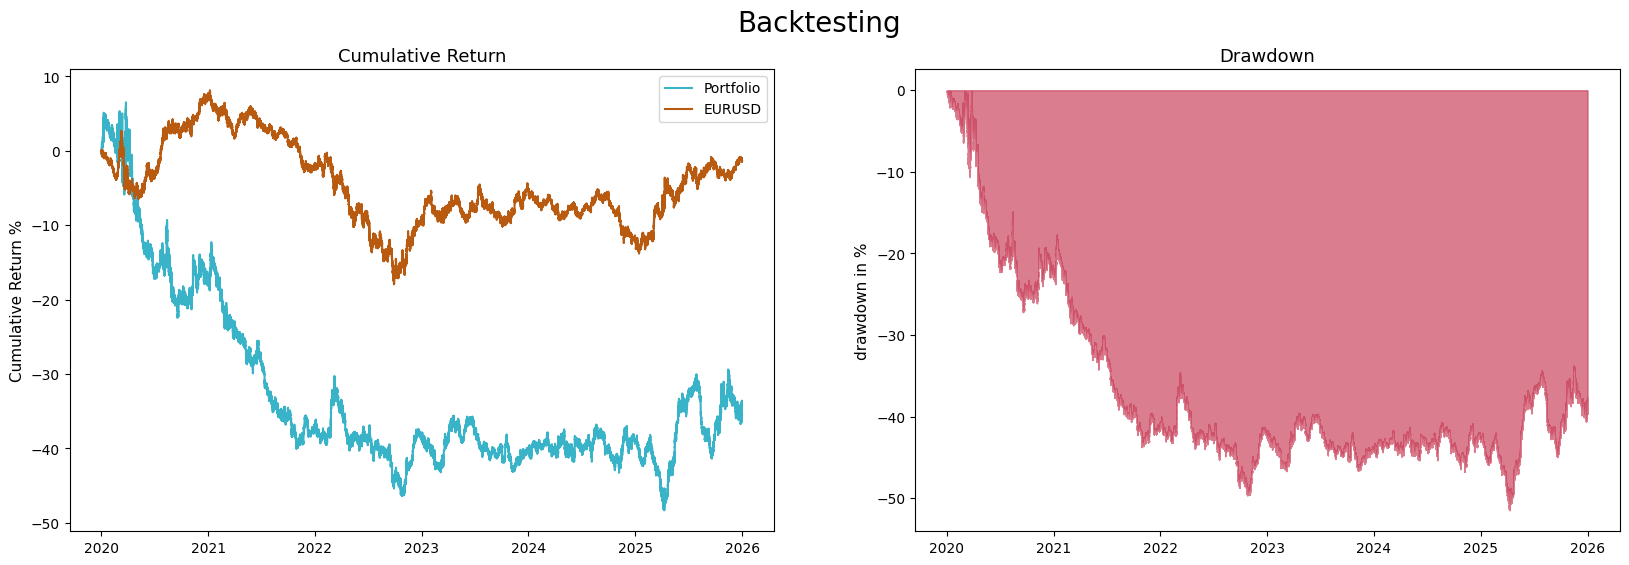

Final Return Portfolio: -35.57%
Final Return EURUSD: -1.29%
Sortino: -0.523
Beta: 0.003
Alpha: -6.344 %
MaxDrawdown: 51.489 %


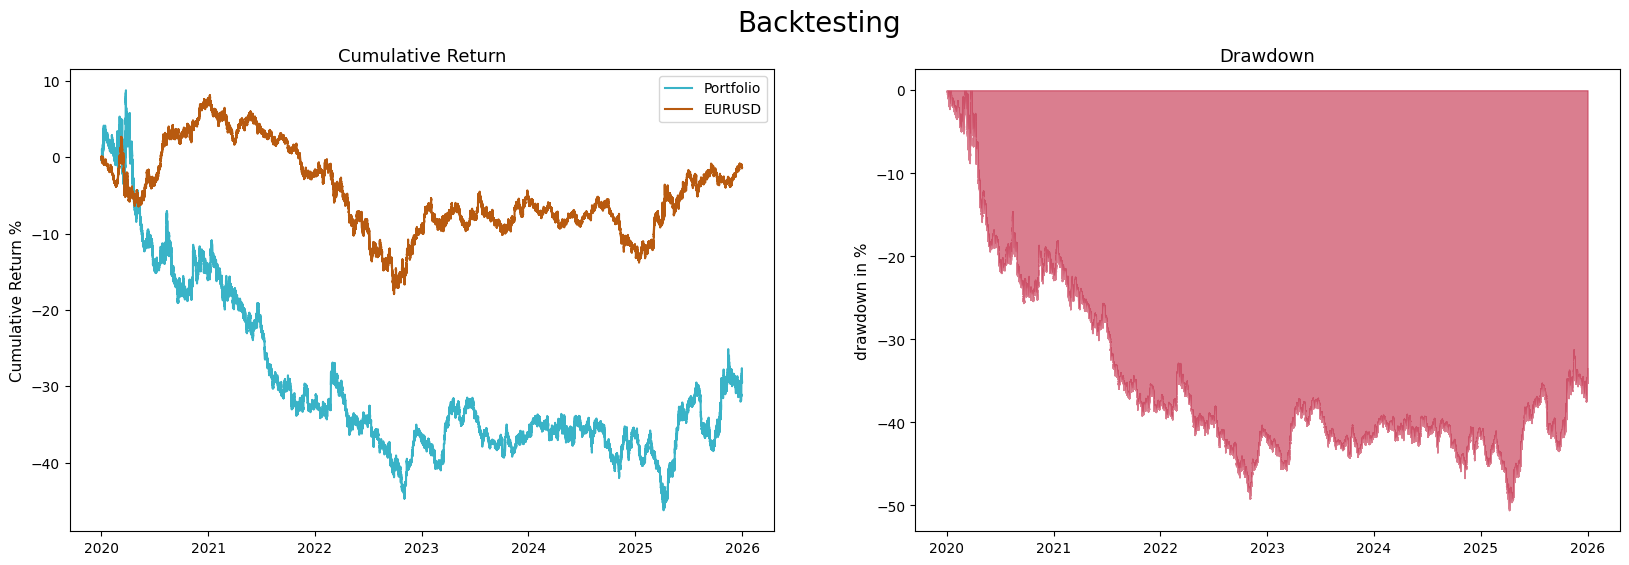

Final Return Portfolio: -29.41%
Final Return EURUSD: -1.29%
Sortino: -0.392
Beta: 0.004
Alpha: -4.756 %
MaxDrawdown: 50.585 %


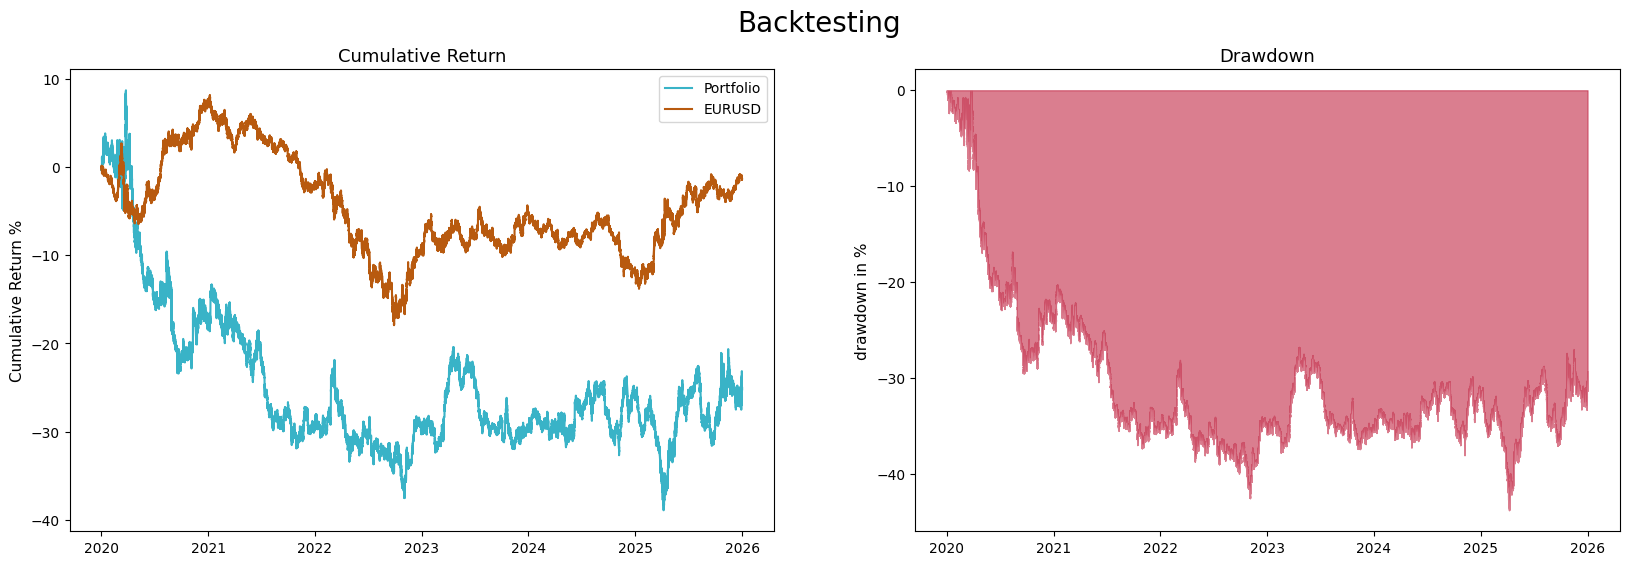

Final Return Portfolio: -25.17%
Final Return EURUSD: -1.29%
Sortino: -0.307
Beta: 0.004
Alpha: -3.741 %
MaxDrawdown: 43.795 %


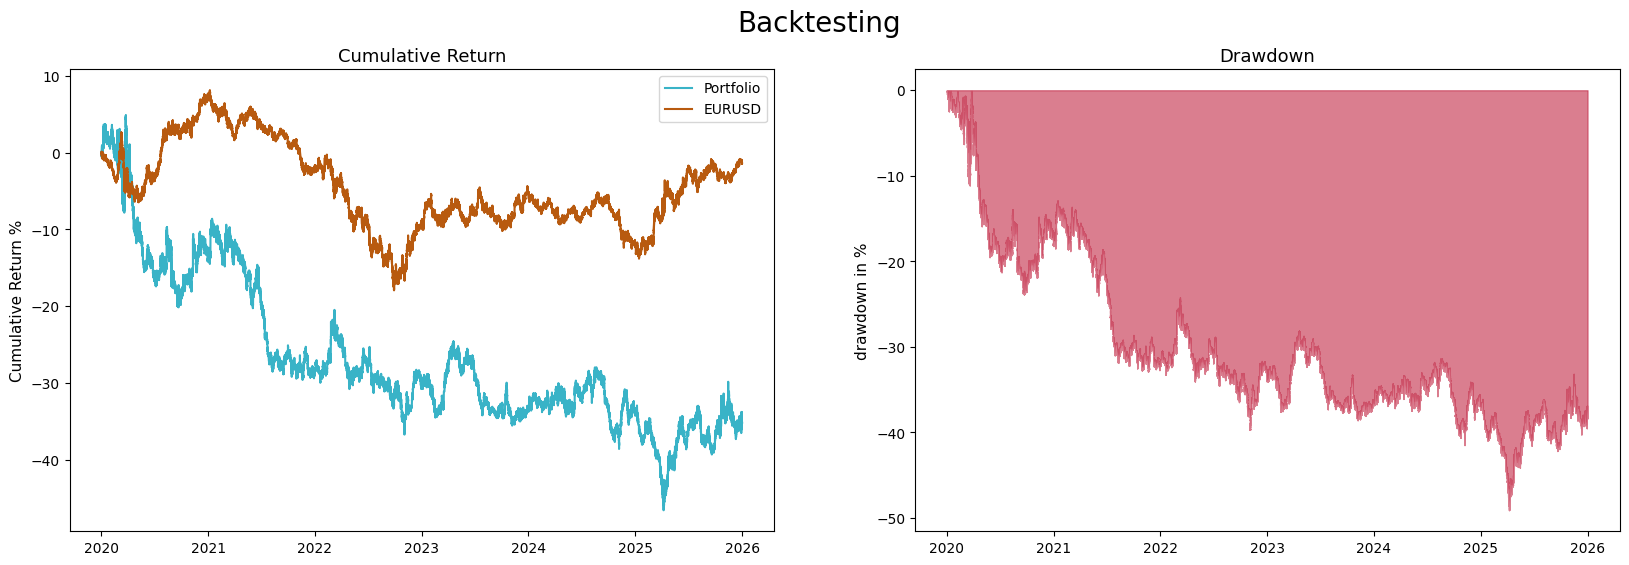

Final Return Portfolio: -35.19%
Final Return EURUSD: -1.29%
Sortino: -0.512
Beta: 0.002
Alpha: -6.242 %
MaxDrawdown: 49.113 %


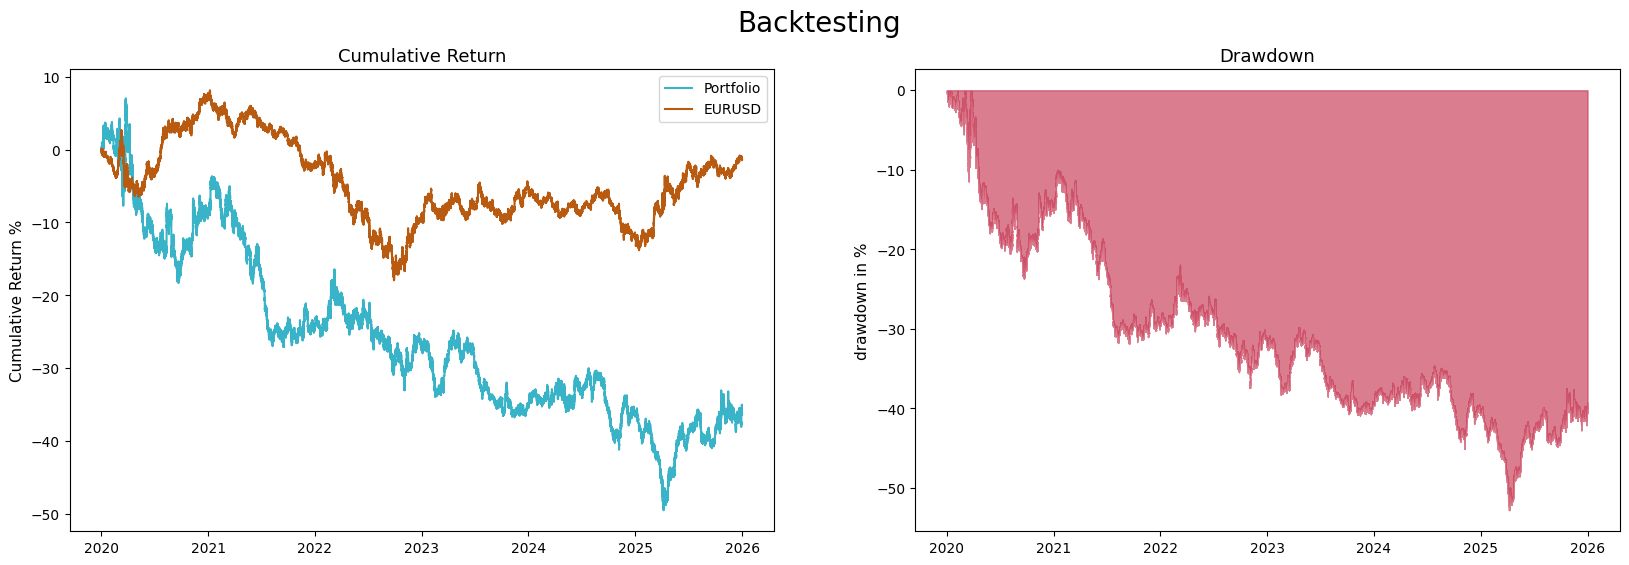

Final Return Portfolio: -36.28%
Final Return EURUSD: -1.29%
Sortino: -0.536
Beta: 0.001
Alpha: -6.537 %
MaxDrawdown: 52.817 %


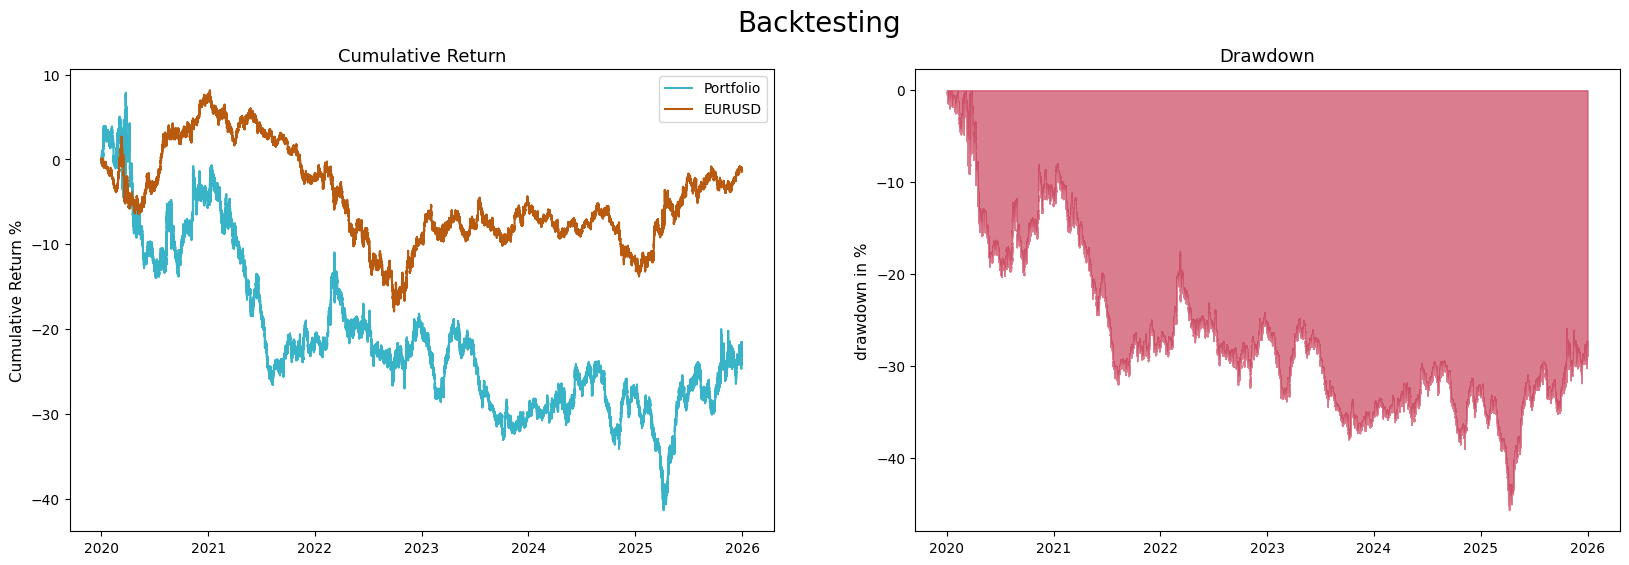

Final Return Portfolio: -23.13%
Final Return EURUSD: -1.29%
Sortino: -0.269
Beta: -0.0
Alpha: -3.272 %
MaxDrawdown: 45.661 %


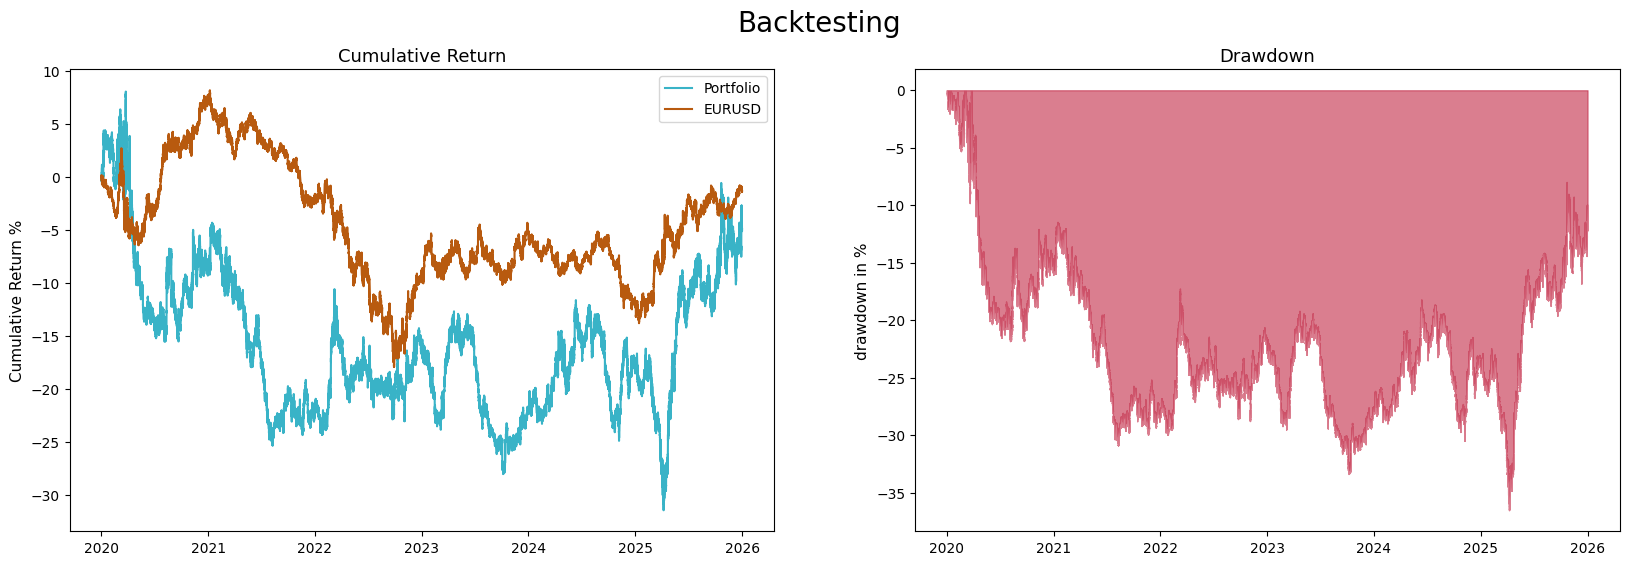

Final Return Portfolio: -4.93%
Final Return EURUSD: -1.29%
Sortino: 0.035
Beta: -0.001
Alpha: 0.427 %
MaxDrawdown: 36.537 %


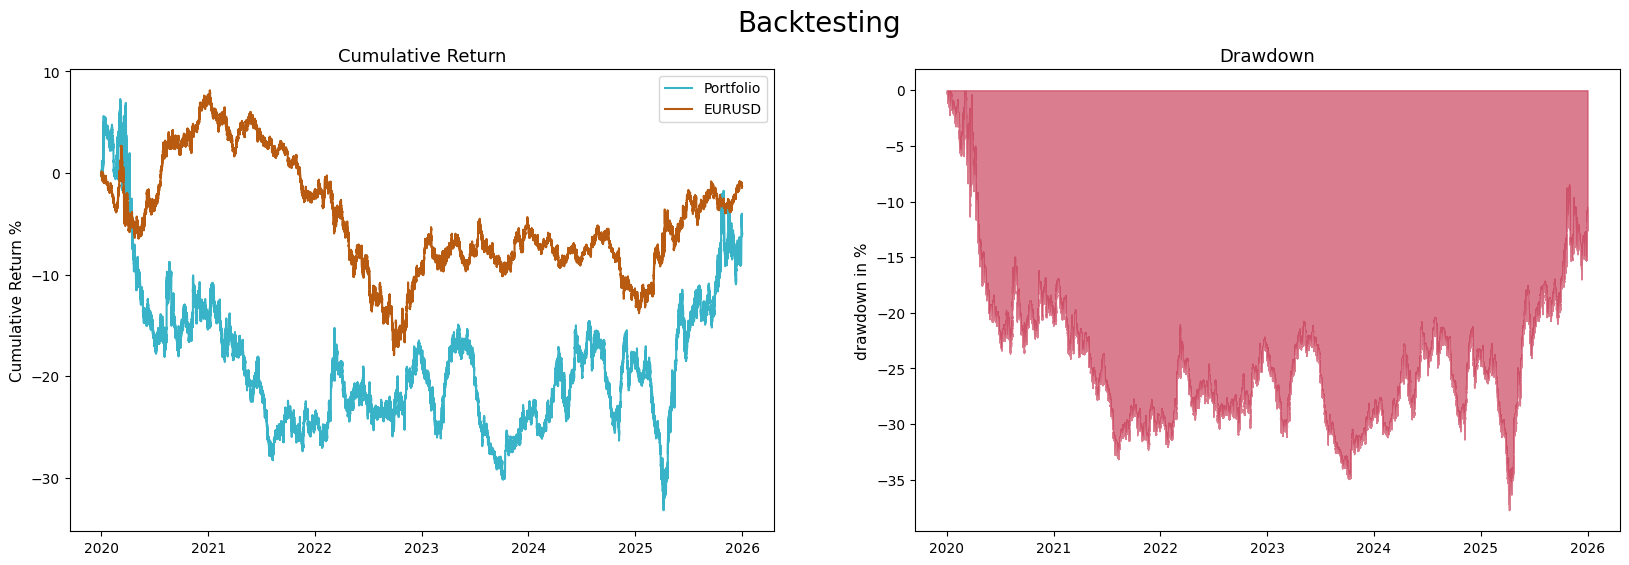

Final Return Portfolio: -6.03%
Final Return EURUSD: -1.29%
Sortino: 0.019
Beta: -0.001
Alpha: 0.226 %
MaxDrawdown: 37.757 %


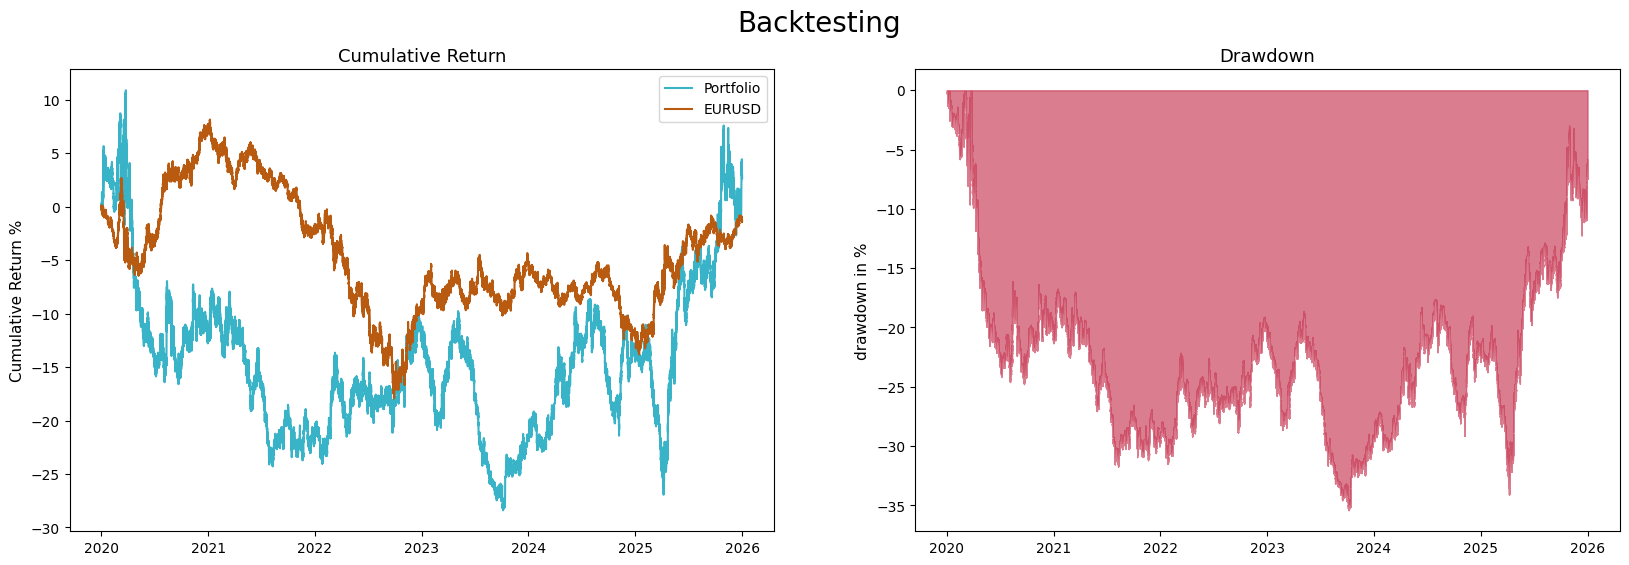

Final Return Portfolio: 2.72%
Final Return EURUSD: -1.29%
Sortino: 0.146
Beta: 0.0
Alpha: 1.775 %
MaxDrawdown: 35.419 %


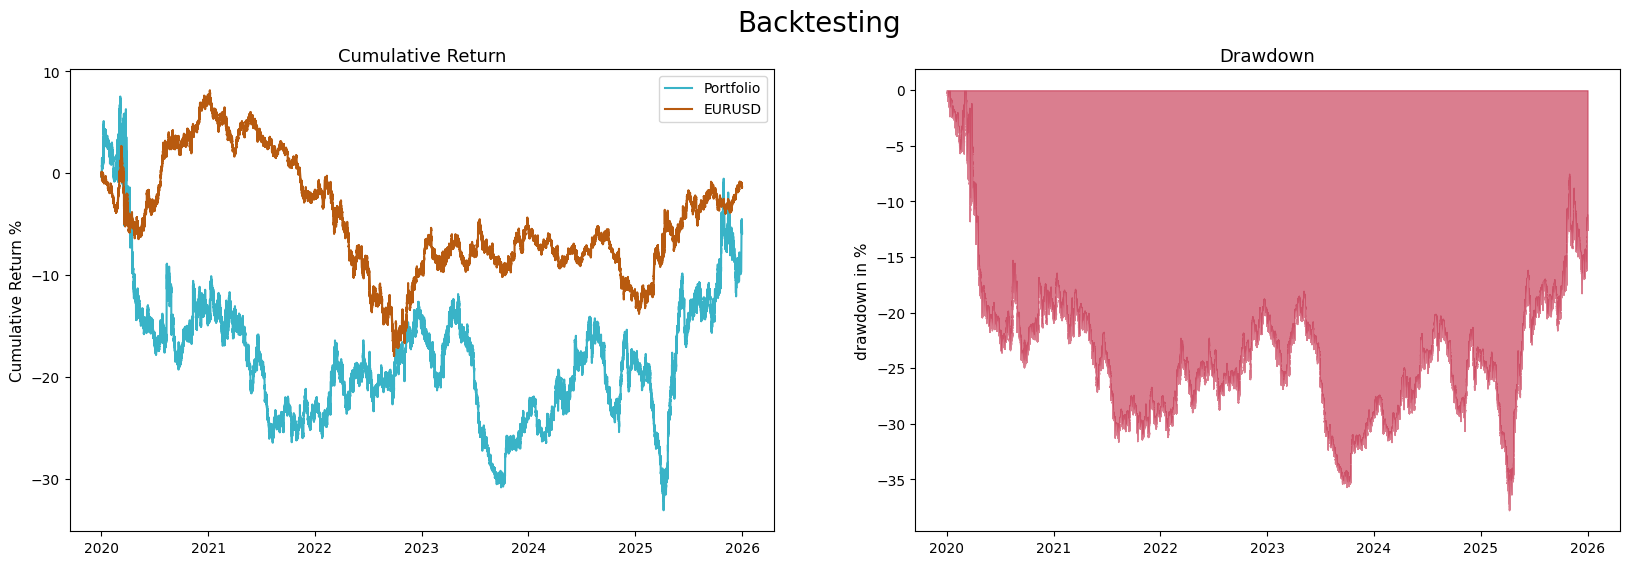

Final Return Portfolio: -5.91%
Final Return EURUSD: -1.29%
Sortino: 0.02
Beta: 0.001
Alpha: 0.247 %
MaxDrawdown: 37.774 %


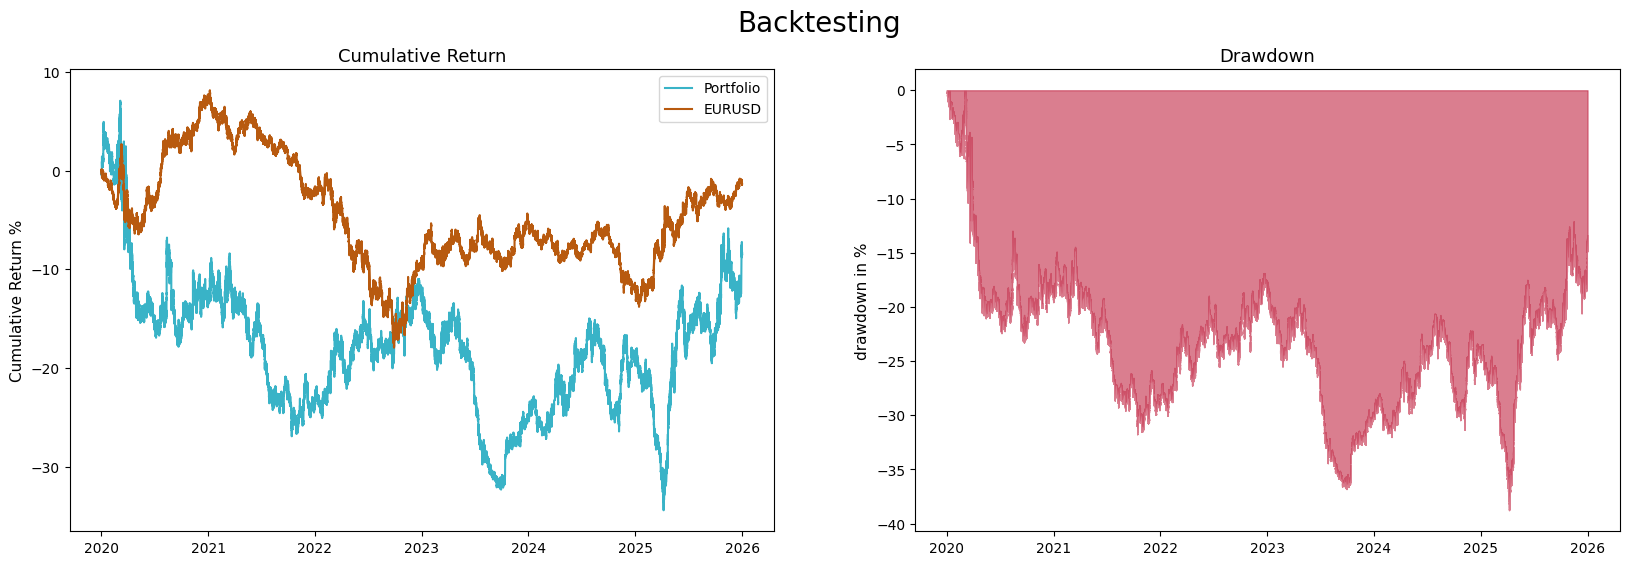

Final Return Portfolio: -8.53%
Final Return EURUSD: -1.29%
Sortino: -0.02
Beta: 0.002
Alpha: -0.244 %
MaxDrawdown: 38.774 %


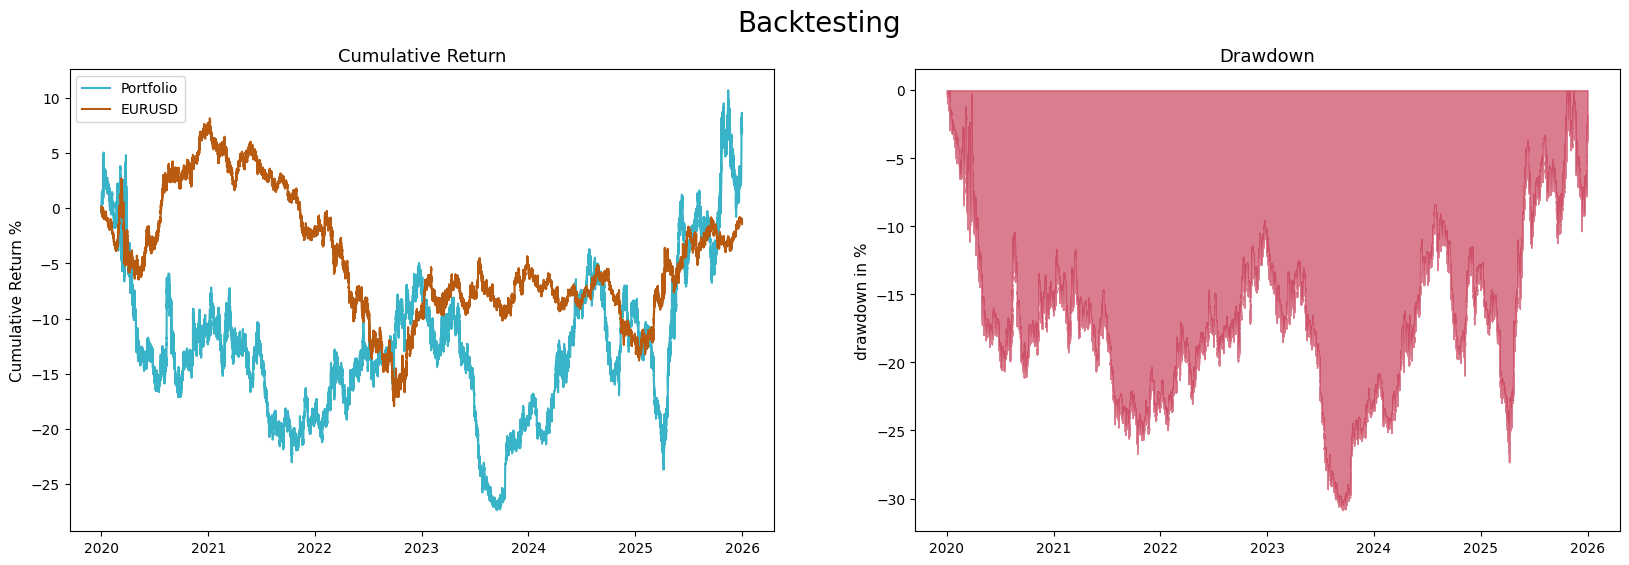

Final Return Portfolio: 6.97%
Final Return EURUSD: -1.29%
Sortino: 0.203
Beta: 0.002
Alpha: 2.48 %
MaxDrawdown: 30.864 %


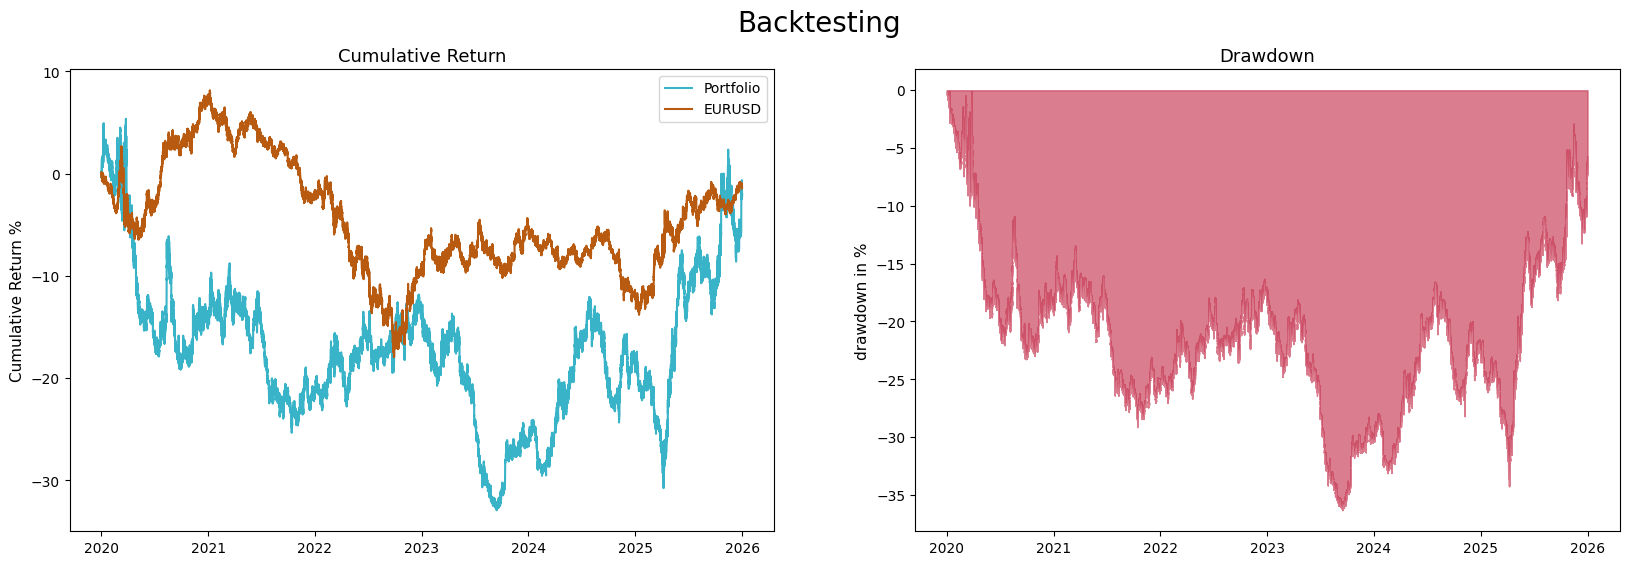

Final Return Portfolio: -2.21%
Final Return EURUSD: -1.29%
Sortino: 0.075
Beta: 0.002
Alpha: 0.919 %
MaxDrawdown: 36.329 %


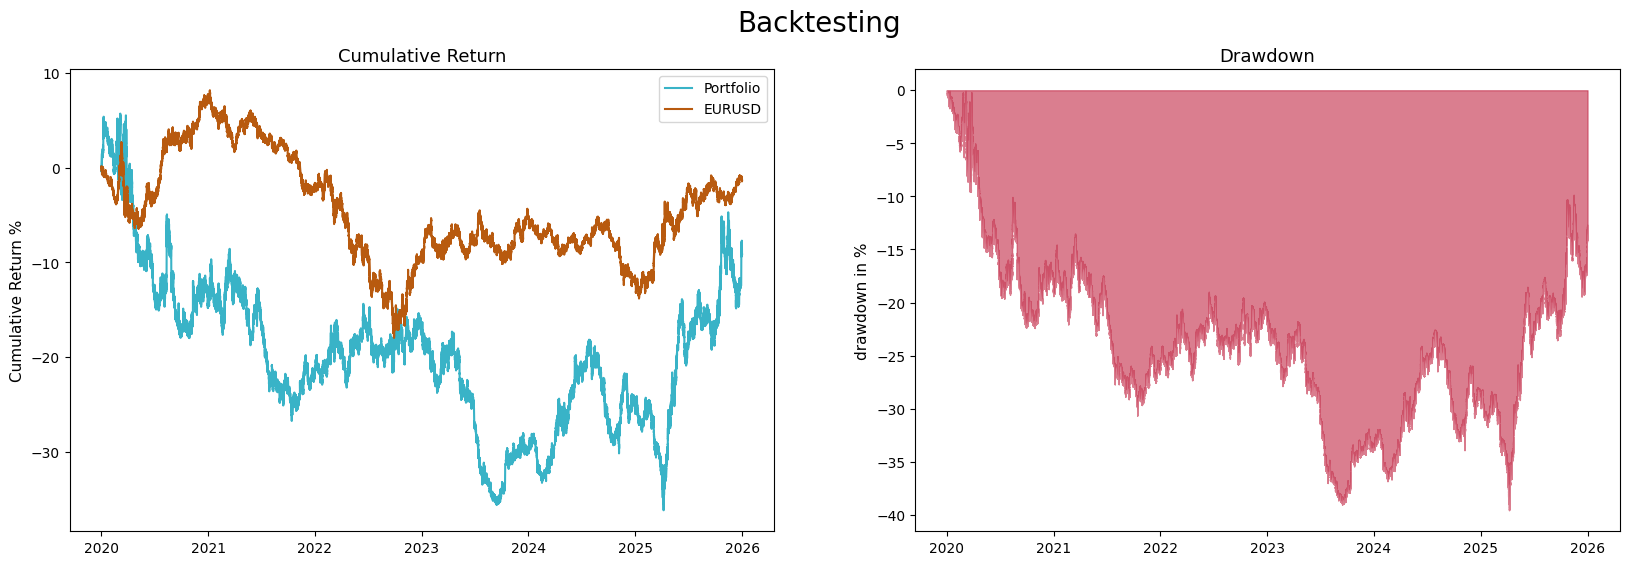

Final Return Portfolio: -9.18%
Final Return EURUSD: -1.29%
Sortino: -0.03
Beta: 0.002
Alpha: -0.368 %
MaxDrawdown: 39.571 %


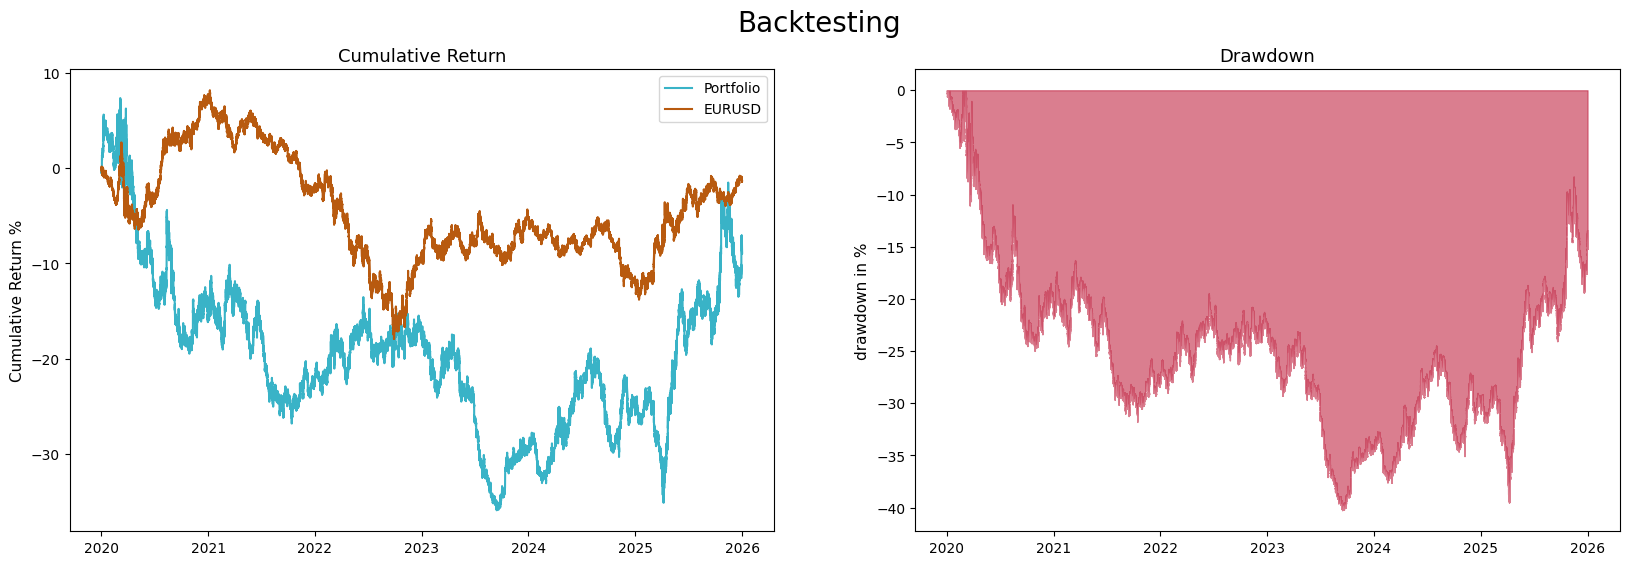

Final Return Portfolio: -8.93%
Final Return EURUSD: -1.29%
Sortino: -0.026
Beta: 0.003
Alpha: -0.32 %
MaxDrawdown: 40.259 %


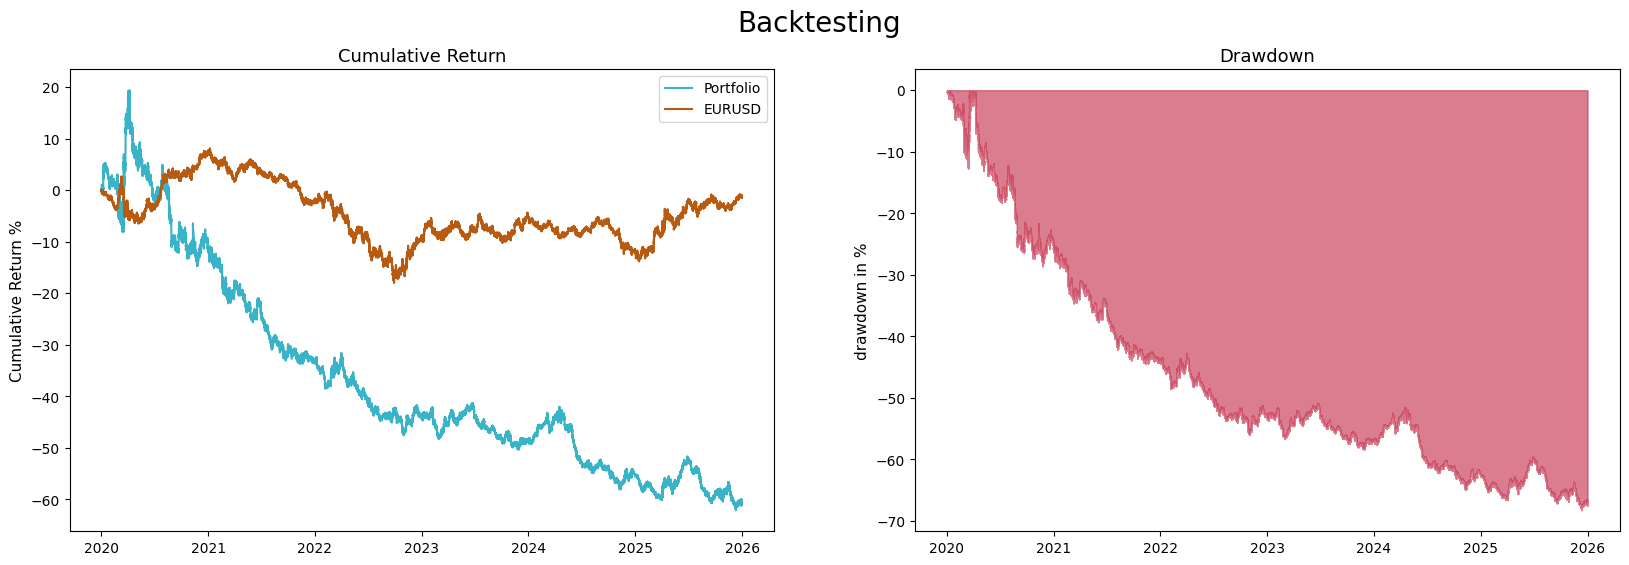

Final Return Portfolio: -60.73%
Final Return EURUSD: -1.29%
Sortino: -1.234
Beta: -0.005
Alpha: -14.961 %
MaxDrawdown: 68.286 %


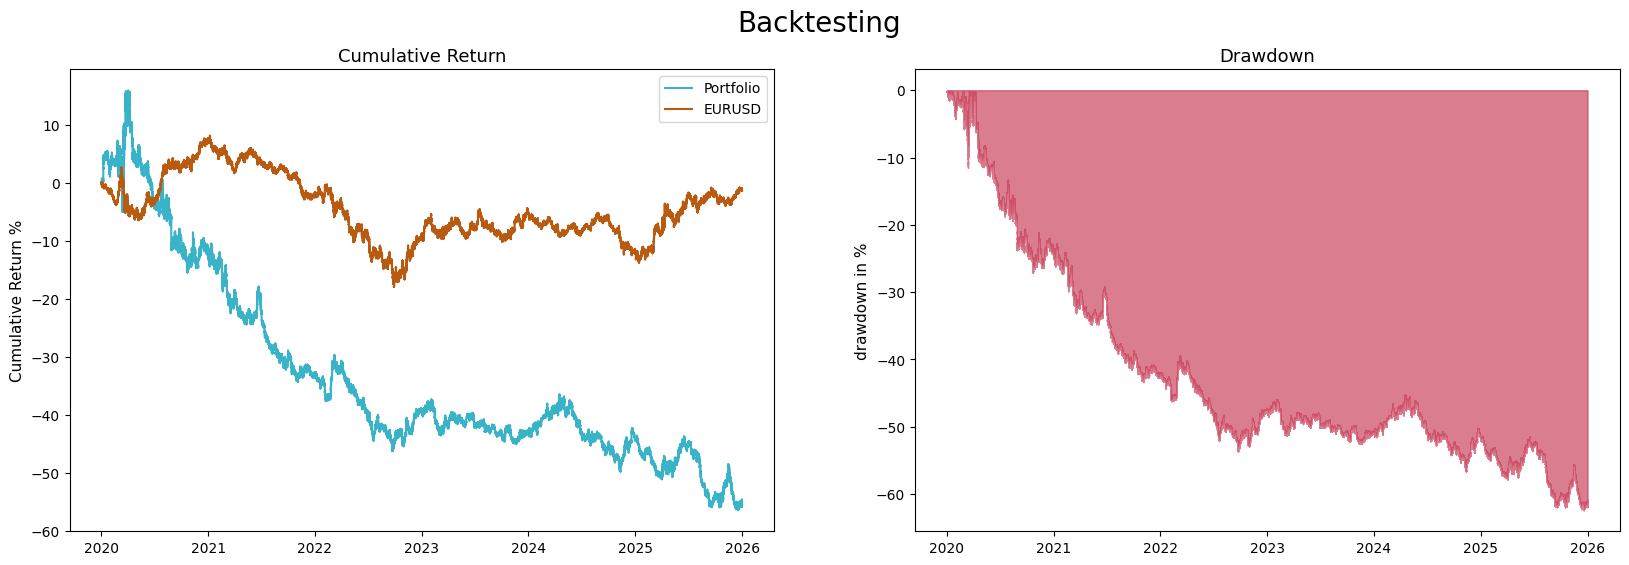

Final Return Portfolio: -55.39%
Final Return EURUSD: -1.29%
Sortino: -1.048
Beta: -0.004
Alpha: -12.742 %
MaxDrawdown: 62.412 %


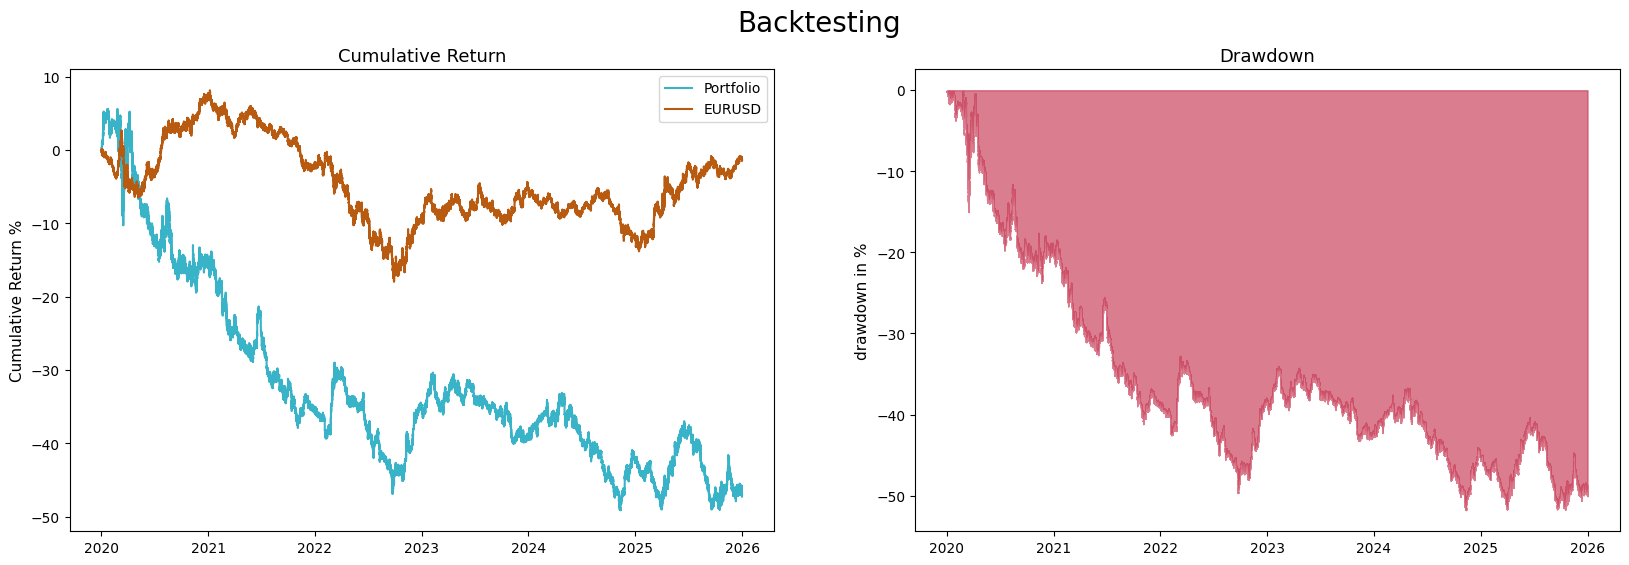

Final Return Portfolio: -46.93%
Final Return EURUSD: -1.29%
Sortino: -0.798
Beta: 0.0
Alpha: -9.72 %
MaxDrawdown: 51.815 %


In [ ]:
fast_windows = range(10, 55, 5)
slow_windows = range(20, 125, 5)
results = []

df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")

for fast_window in fast_windows:
    for slow_window in slow_windows:
        if fast_window >= slow_window:
            continue
        temp = df_GOLD.copy()

        df_GOLD = get_resampled(temp, high_freq="5min")
        dfc = SMA_strategy(temp, SMA_Fast = fast_window, SMA_Slow = slow_window, transaction_cost=0.00001)
        metrics = BackTest(dfc, df_baseline, selected_timeframe)

        results.append({
            "fast_window": fast_window,
            "slow_window": slow_window,
            "cumulative_return": metrics["final_return_portfolio"] * 100,
            "final_return_benchmark": metrics["final_return_benchmark"] * 100,
            "sortino": metrics["sortino"],
            "beta": metrics["beta"],
            "alpha": metrics["alpha"],
            "max_drawdown": metrics["max_drawdown"],
        })

optimization_results = pd.DataFrame(results)

if optimization_results.empty:
    print("No valid parameter sets found. Try wider ranges or looser filters.")
else:
    optimization_results = optimization_results.sort_values(
        by=["cumulative_return"], ascending=False
    ).reset_index(drop=True)

    best_fast_window = int(optimization_results.loc[0, "fast_window"])
    best_slow_window = int(optimization_results.loc[0, "slow_window"])

    print(f"Best fast SMA: {best_fast_window}")
    print(f"Best slow SMA: {best_slow_window}")
    print(f"Best cumulative return: {optimization_results.loc[0, 'cumulative_return']:.2%}")
    print(f"Best trade count: {int(optimization_results.loc[0, 'trade_count'])}")
    display(optimization_results.head(10))

## Build SMA Crossover - Detection aginst ranging markets
### Version 1

In [ ]:
def SMA_strategy_sloop(df=df_GOLD_Raw, SMA_Fast = 30, SMA_Slow = 60, vol_window = 20, vol_ma_window = 20, spread_q = 0.5, slope_q = 0.5, transaction_cost=0.0):
  
    df = df.copy()

  # Create fast and slow SMAs
    df["SMA_fast"] = df["close"].rolling(window=SMA_Fast).mean()
    df["SMA_slow"] = df["close"].rolling(window=SMA_Slow).mean()
    df["sma_spread"] = (df["SMA_fast"] - df["SMA_slow"]).abs() / df["close"]
    df["slow_slope"] = df["SMA_slow"].diff(5).abs() / df["close"]
    df["volatility"] = df["close"].pct_change().rolling(vol_window).std()
    df["volatility_ma"] = df["volatility"].rolling(vol_ma_window).median()

    spread_threshold = df["sma_spread"].quantile(spread_q)
    slope_threshold = df["slow_slope"].quantile(slope_q)

    trend_filter = (
        (df["sma_spread"] > spread_threshold)
        & (df["slow_slope"] > slope_threshold)
        & (df["volatility"] > df["volatility_ma"])
    )

    long_regime = (df["SMA_fast"] > df["SMA_slow"]) & trend_filter
    short_regime = (df["SMA_fast"] < df["SMA_slow"]) & trend_filter

    df["position"] = 0
    df.loc[long_regime, "position"] = 1
    df.loc[short_regime, "position"] = -1

    df["pct"] = df["close"].pct_change(1)

    # Apply transaction cost only when a position change occurs
    turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
    df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

    # Keep only valid strategy returns; avoids plotting an all-NaN series
    ret = df["return"].dropna()
    if ret.empty:
        raise ValueError("No valid returns. Download more history or reduce SMA windows.")

    return ret

In [ ]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
dfc = SMA_strategy_sloop(df_GOLD, SMA_Fast = 30, SMA_Slow = 60, vol_window = 20, vol_ma_window = 20, spread_q = 0.5, slope_q = 0.5, transaction_cost=0.00001)
metrics = BackTest(dfc, df_baseline, selected_timeframe)

Finding the best parameters for the new strategy.

In [ ]:
fast_windows = range(10, 55, 5)
slow_windows = range(20, 125, 5)
vol_windows = [10, 20, 30]
vol_ma_windows = [50, 100, 150]
spread_quantiles = [0.50, 0.55, 0.60]
slope_quantiles = [0.50, 0.55, 0.60]
results = []

df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")

for fast_window in fast_windows:
    for slow_window in slow_windows:
        if fast_window >= slow_window:
            continue
        temp = df_GOLD.copy()

        for vol_window in vol_windows:
            for vol_ma_window in vol_ma_windows:
                for spread_q in spread_quantiles:
                    for slope_q in slope_quantiles:

                        df_GOLD = get_resampled(temp, high_freq="5min")
                        dfc = SMA_strategy_sloop(df_GOLD, SMA_Fast = fast_window, SMA_Slow = slow_window, vol_window = vol_window, vol_ma_window = vol_ma_window, spread_q = spread_q, slope_q = slope_q, transaction_cost=0.00001)
                        metrics = BackTest(dfc, df_baseline, selected_timeframe)

                        results.append({
                            "fast_window": fast_window,
                            "slow_window": slow_window,
                            "cumulative_return": metrics["final_return_portfolio"] * 100,
                            "final_return_benchmark": metrics["final_return_benchmark"] * 100,
                            "sortino": metrics["sortino"],
                            "beta": metrics["beta"],
                            "alpha": metrics["alpha"],
                            "max_drawdown": metrics["max_drawdown"],
                        })

optimization_results = pd.DataFrame(results)

if optimization_results.empty:
    print("No valid parameter sets found. Try wider ranges or looser filters.")
else:
    optimization_results = optimization_results.sort_values(
        by=["cumulative_return"], ascending=False
    ).reset_index(drop=True)

    best_fast_window = int(optimization_results.loc[0, "fast_window"])
    best_slow_window = int(optimization_results.loc[0, "slow_window"])

    print(f"Best fast SMA: {best_fast_window}")
    print(f"Best slow SMA: {best_slow_window}")
    print(f"Best cumulative return: {optimization_results.loc[0, 'cumulative_return']:.2%}")
    print(f"Best trade count: {int(optimization_results.loc[0, 'trade_count'])}")
    display(optimization_results.head(10))